# Book Search Engine Evaluation

This notebook demonstrates a simple evaluation workflow for an information retrieval system. The aim is to calculate Precision@k, Recall@k, and F1-score@k for example book-search queries, then compare the average performance across different query types.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


## Evaluation Approach

For each query, the evaluation records the number of relevant books retrieved in the top `k` results and compares this with the total number of relevant results identified in the top 100. This provides an approximate recall value while keeping the manual relevance-judgement process manageable for a large book-summary dataset.

In [1]:
#Initialise the dataframe
columns = ['Query', 'Query type', 'Precision', 'Recall', 'F1']
results = pd.DataFrame(columns=columns)

In [2]:
def evaluate_query(k,relevant_retrieved,total_relevant):
    """
    Computes Precision@k, Recall@k, and F1-score@k for a given query.

    Parameters:
    - k: Cutoff rank
    - relevant_retrieved: Number of relevent results in top k
    - total_relevant: Number of relevant results for the query in the top 100 results.

    Returns:
    - precision, recall, f1_score
    """
    precision = relevant_retrieved / k if k else 0
    recall = relevant_retrieved / total_relevant if total_relevant else 0
    f1 = (2 * precision * recall / (precision + recall)) if (precision + recall) else 0

    print(f"\nPrecision@{k}: {precision}")
    print(f"Recall@{k}: {recall}")
    print(f"F1-score@{k}: {f1}\n")

    return precision,recall,f1


In [72]:
query = "A book about a heist"
query_type = 'Plot/setting'
k = 5
relevant_retrieved = 1
total_relevant = 8

precision,recall,f1 = evaluate_query(k,relevant_retrieved,total_relevant)


Precision@5: 0.2
Recall@5: 0.125
F1-score@5: 0.15384615384615385



In [73]:
results.loc[len(results)] = [query,query_type, precision, recall, f1]
display(results)

,Query,Query type,Precision,Recall,F1
0,Books written by Steven King,Author,0.8,0.066667,0.123077
1,Novels by Jane Austen,Author,0.8,0.444444,0.571429
2,J.K. Rowling's fantasy series,Author,0.6,0.300000,0.400000
3,Classic literature by Charles Dickens,Author,1.0,0.250000,0.400000
4,Books by George Orwell,Author,1.0,0.625000,0.769231
5,Mathematics,Genres,0.4,0.666667,0.500000
6,Thriller books,Genres,1.0,0.052632,0.100000
7,Medical thriller about virus outbreak,Genres,0.8,0.250000,0.380952
8,Book featuring a rebellious teenager,Plot/setting,0.2,0.066667,0.100000
9,Book set in WW2 in Europe,Plot/setting,0.0,0.000000,0.000000


## Aggregated Results

The final section groups the query-level results by query type and plots the average precision, recall, and F1-score for each group. This makes it easier to compare how the retrieval system performs for different kinds of search intent.

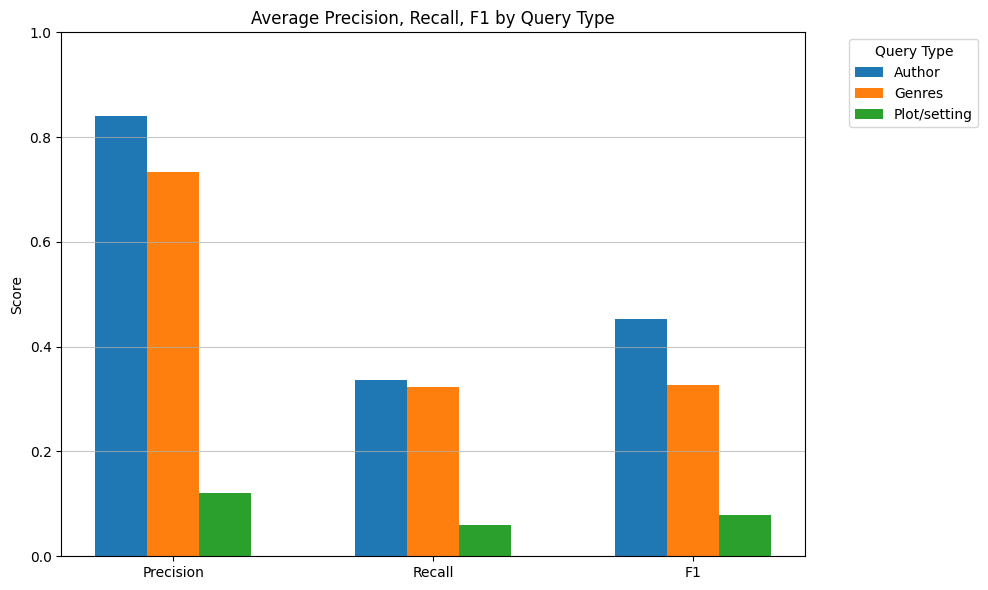

In [74]:
grouped = results.groupby('Query type')[['Precision', 'Recall', 'F1']].mean().T
grouped

fig, ax = plt.subplots(figsize=(10, 6))

metrics = grouped.index
topics = grouped.columns
bar_width = 0.2
x = np.arange(len(metrics))

for i, topic in enumerate(topics):
    ax.bar(x + i * bar_width, grouped[topic], width=bar_width, label=topic)

ax.set_xticks(x + bar_width)
ax.set_xticklabels(metrics)
ax.set_ylabel('Score')
ax.set_ylim(0, 1)
ax.set_title('Average Precision, Recall, F1 by Query Type')
ax.legend(title='Query Type', bbox_to_anchor=(1.05, 1), loc='upper left')
ax.grid(axis='y', alpha=0.7)

plt.tight_layout()
plt.show()
